In [ ]:
# ── Dependencies ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)
from sklearn.preprocessing import LabelEncoder

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Load & Explore the Data

In [ ]:
# Load Titanic dataset (built into seaborn)
df_raw = sns.load_dataset('titanic')

print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Missing values summary
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing.to_string())

Columns with missing values:
deck           688
age            177
embarked         2
embark_town      2


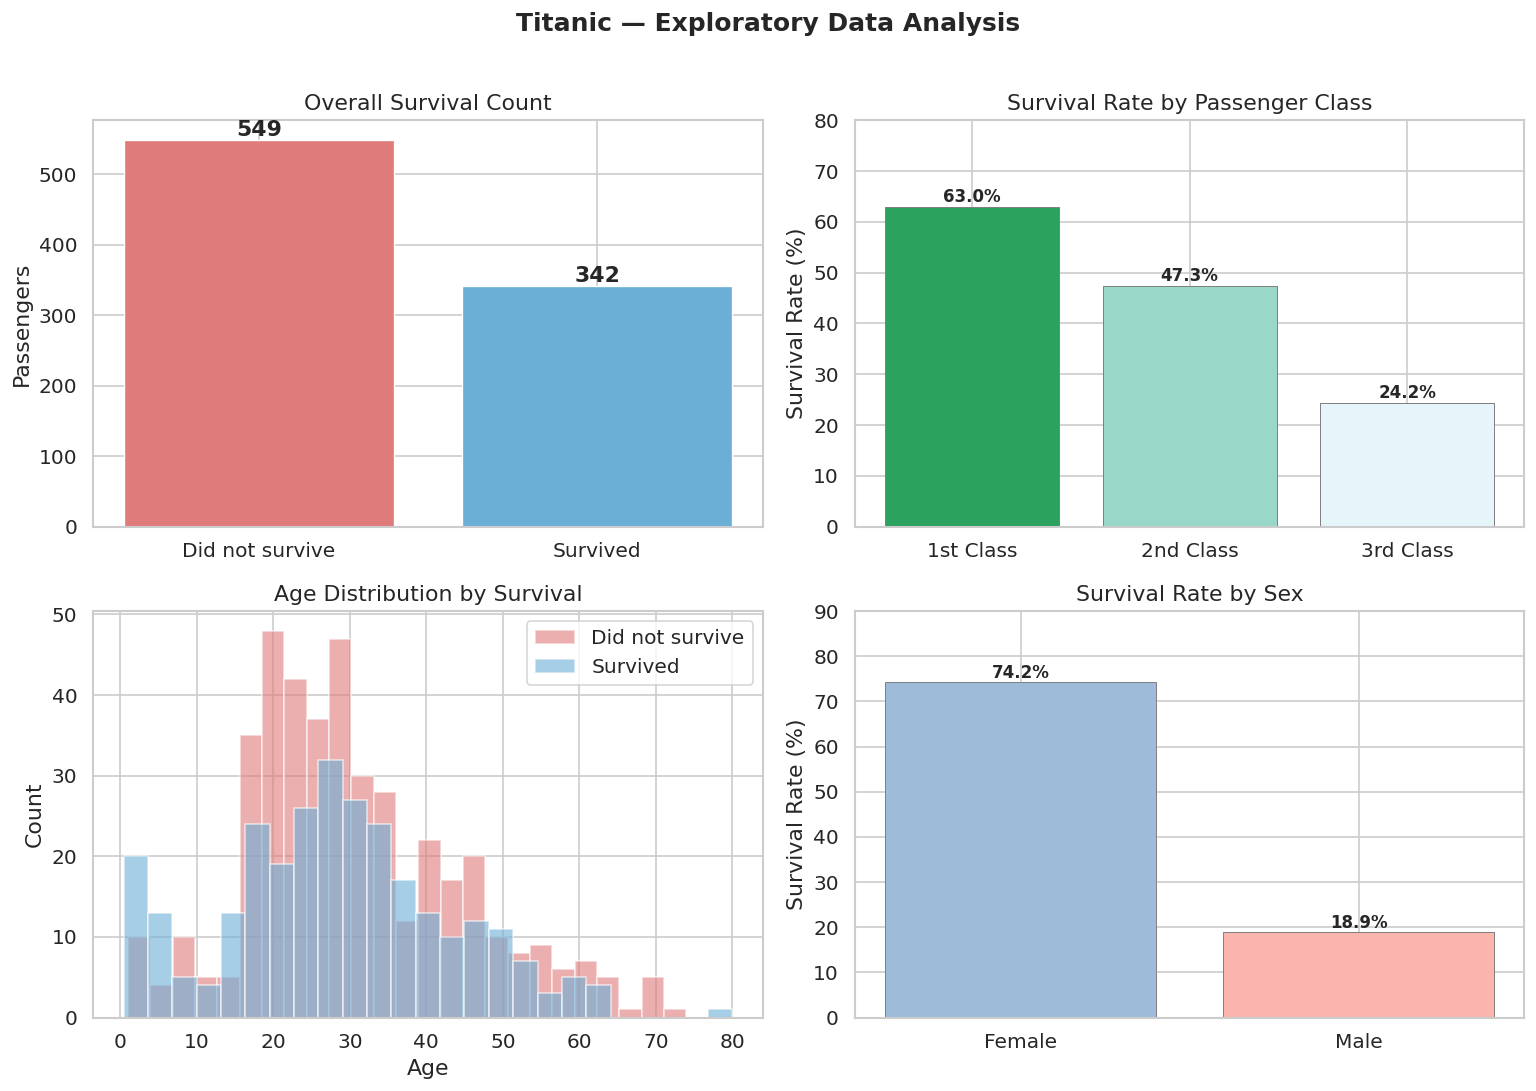

Saved: eda_overview.png


In [ ]:
# ── EDA: 4-panel overview ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Titanic — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)

# 1. Survival rate overall
ax = axes[0, 0]
counts = df_raw['survived'].value_counts()
bars = ax.bar(['Did not survive', 'Survived'], counts.values,
               color=['#e07b7b', '#6baed6'], edgecolor='white', linewidth=0.8)
ax.set_title('Overall Survival Count')
ax.set_ylabel('Passengers')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')

# 2. Survival by passenger class
ax = axes[0, 1]
pclass_survival = df_raw.groupby('pclass')['survived'].mean() * 100
bars = ax.bar(pclass_survival.index.map({1:'1st Class', 2:'2nd Class', 3:'3rd Class'}),
               pclass_survival.values, color=['#2ca25f', '#99d8c9', '#e5f5f9'],
               edgecolor='gray', linewidth=0.6)
ax.set_title('Survival Rate by Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
for bar, val in zip(bars, pclass_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

# 3. Age distribution by survival
ax = axes[1, 0]
for survived, label, color in [(0, 'Did not survive', '#e07b7b'), (1, 'Survived', '#6baed6')]:
    subset = df_raw[df_raw['survived'] == survived]['age'].dropna()
    ax.hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
ax.set_title('Age Distribution by Survival')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

# 4. Survival by sex
ax = axes[1, 1]
sex_survival = df_raw.groupby('sex')['survived'].mean() * 100
bars = ax.bar(sex_survival.index.str.capitalize(), sex_survival.values,
               color=['#9ebcda', '#fbb4ae'], edgecolor='gray', linewidth=0.6)
ax.set_title('Survival Rate by Sex')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 90)
for bar, val in zip(bars, sex_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')

---
## 2. Preprocessing

In [ ]:
# Select features with strong predictive signal
FEATURES = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET   = 'survived'

df = df_raw[FEATURES + [TARGET]].copy()

# Fill missing values
df['age']      = df['age'].fillna(df['age'].median())
df['fare']     = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categoricals
le = LabelEncoder()
df['sex']      = le.fit_transform(df['sex'])       # male=1, female=0
df['embarked'] = le.fit_transform(df['embarked'])  # C=0, Q=1, S=2

print('Missing values after cleaning:', df.isnull().sum().sum())
print(f'Class balance:\n{df[TARGET].value_counts(normalize=True).mul(100).round(1).to_string()}')

Missing values after cleaning: 0
Class balance:
survived
0    61.6
1    38.4


In [ ]:
# Train / test split (80 / 20)
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')

Train: 712 samples | Test: 179 samples


---
## 3. Train the Decision Tree

In [ ]:
# Train — max_depth=4 keeps the tree readable while avoiding overfitting
dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    criterion='gini',
    random_state=RANDOM_STATE
)
dt.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print(f'Train accuracy : {train_acc:.3f}')
print(f'Test  accuracy : {test_acc:.3f}')
print(f'Tree depth     : {dt.get_depth()}')
print(f'Leaf nodes     : {dt.get_n_leaves()}')

Train accuracy : 0.836
Test  accuracy : 0.777
Tree depth     : 4
Leaf nodes     : 14


---
## 4. Evaluation — Confusion Matrix & Classification Report

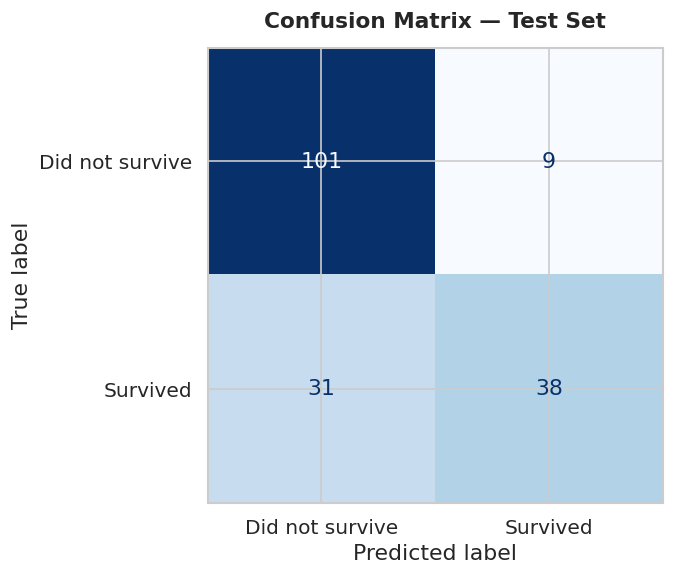

Saved: confusion_matrix.png

Classification Report
───────────────────────────────────────────────────────
                 precision    recall  f1-score   support

Did not survive       0.77      0.92      0.83       110
       Survived       0.81      0.55      0.66        69

       accuracy                           0.78       179
      macro avg       0.79      0.73      0.74       179
   weighted avg       0.78      0.78      0.77       179



In [ ]:
y_pred = dt.predict(X_test)

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Did not survive', 'Survived']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

# ── Classification report ─────────────────────────────────────────────────────
print('\nClassification Report')
print('─' * 55)
print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))

---
## 5. Feature Importances

/tmp/ipykernel_572/1430694349.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([feature_labels.get(f, f) for f in importances.index])


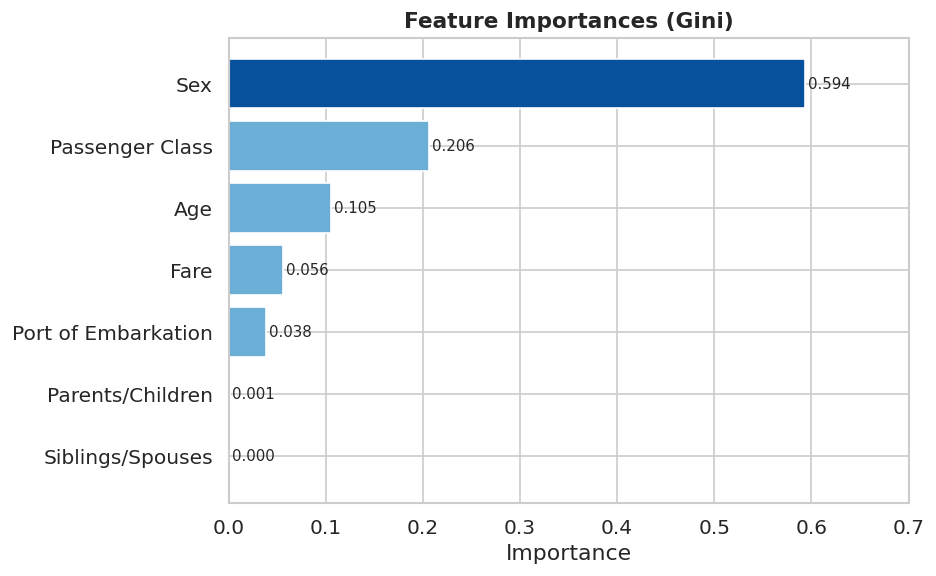

Saved: feature_importances.png


In [ ]:
importances = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#6baed6' if v < importances.max() else '#08519c' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importances (Gini)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_xlim(0, importances.max() * 1.18)

feature_labels = {
    'pclass': 'Passenger Class', 'sex': 'Sex', 'age': 'Age',
    'sibsp': 'Siblings/Spouses', 'parch': 'Parents/Children',
    'fare': 'Fare', 'embarked': 'Port of Embarkation'
}
ax.set_yticklabels([feature_labels.get(f, f) for f in importances.index])

plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importances.png')

---
## 6. Decision Tree Visualization

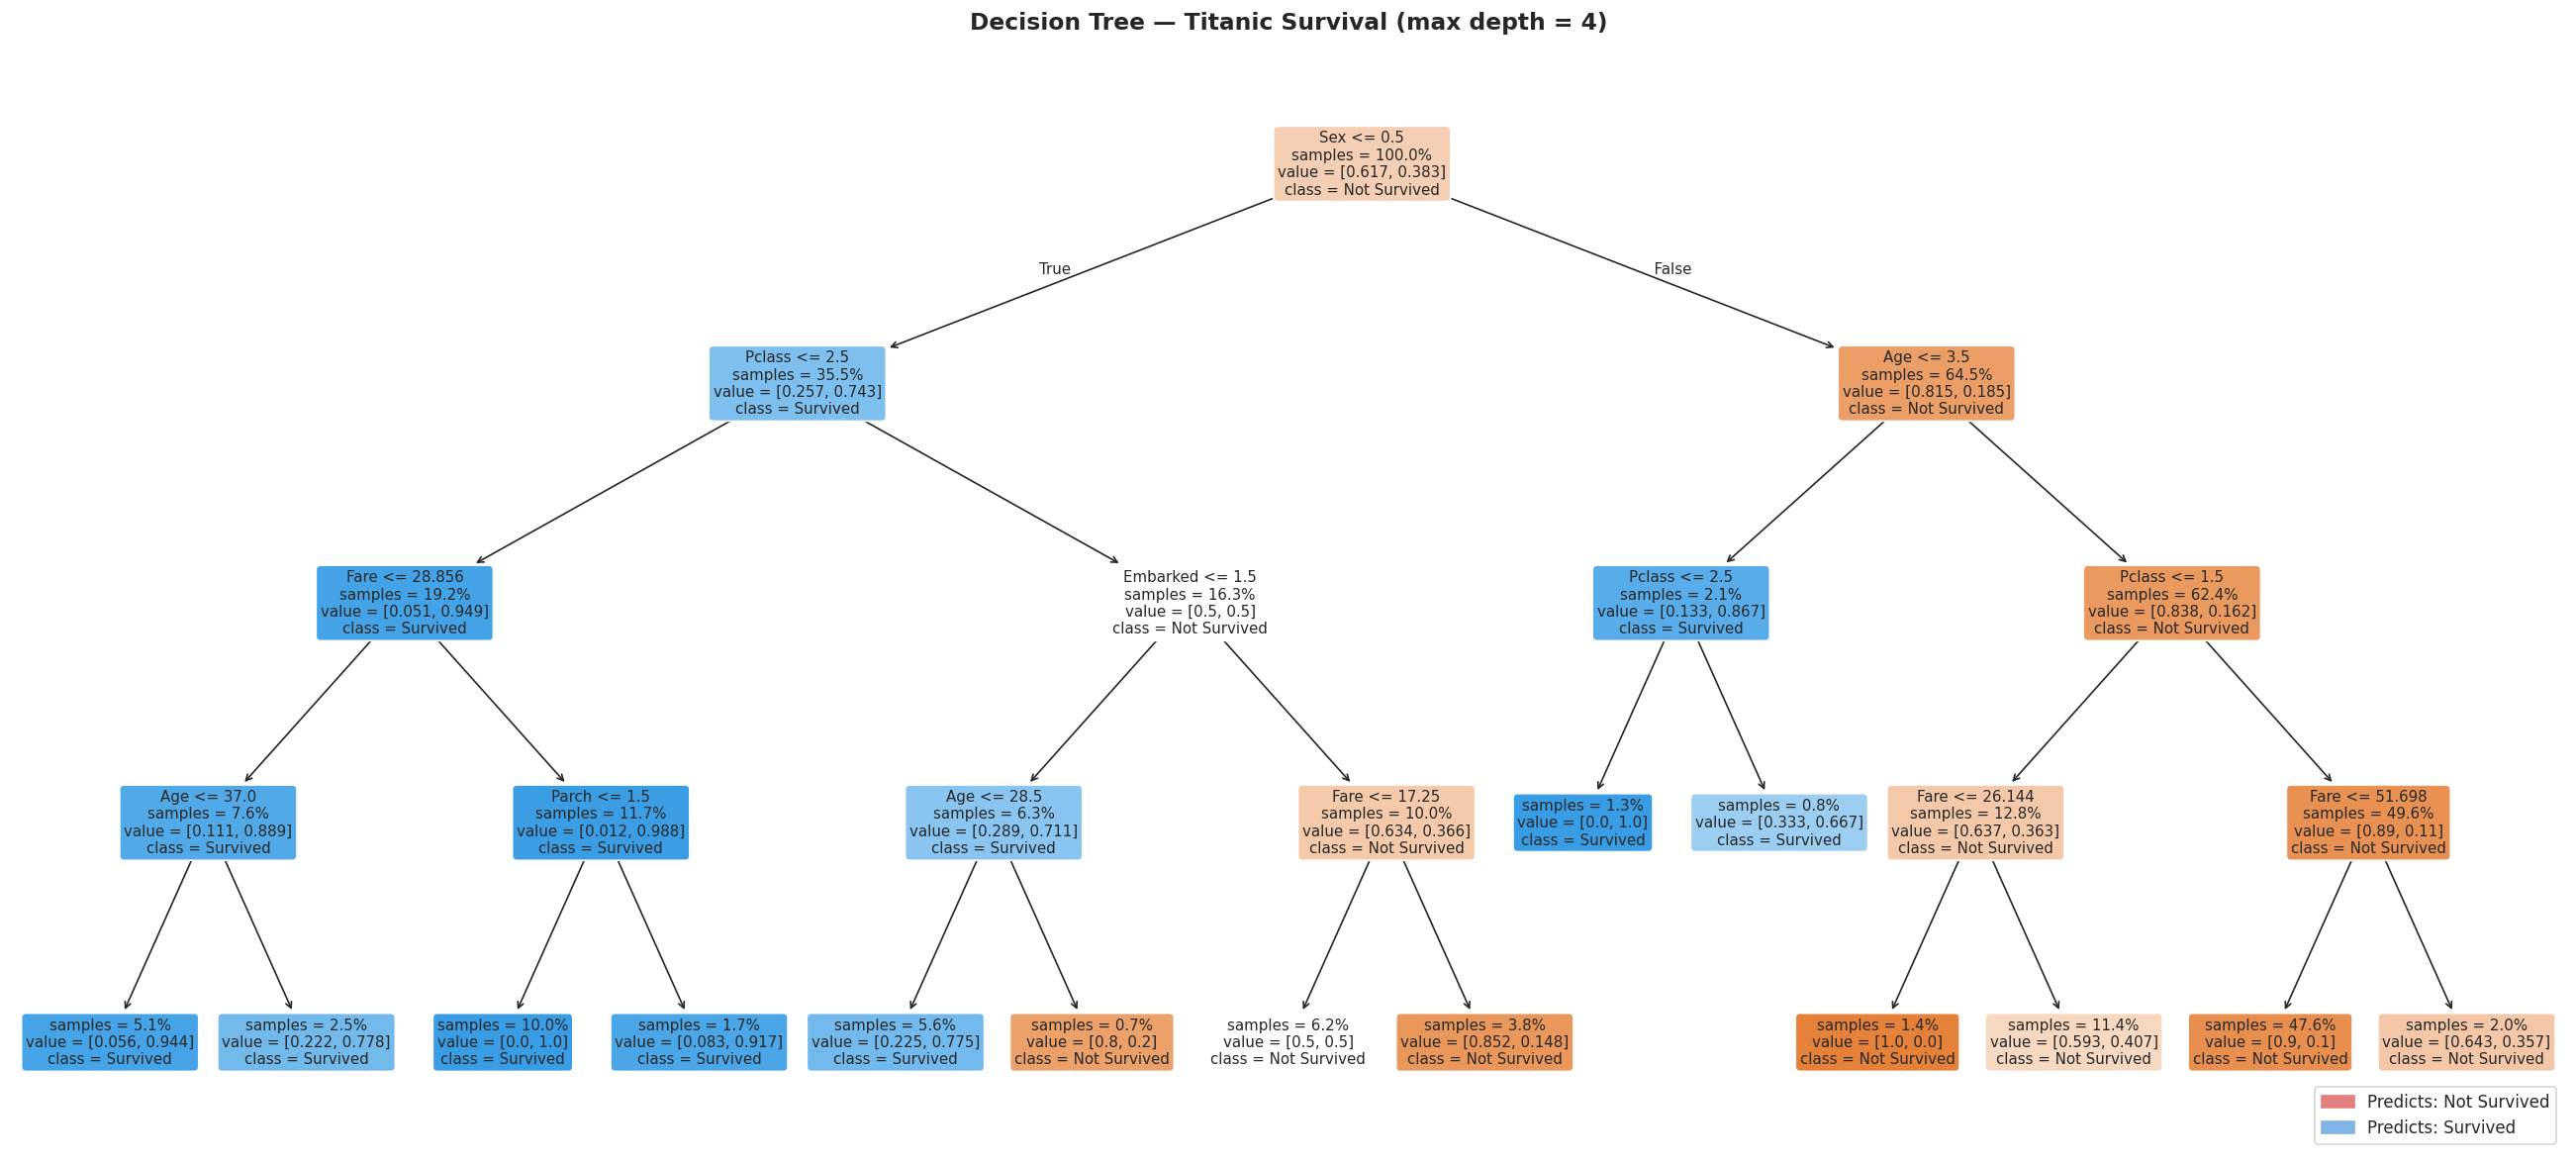

Saved: decision_tree.png


In [ ]:
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    dt,
    feature_names=[
        'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'
    ],
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,
    proportion=True
)

ax.set_title(
    'Decision Tree — Titanic Survival (max depth = 4)',
    fontsize=14, fontweight='bold', pad=15
)

# Legend
legend_handles = [
    mpatches.Patch(color='#e58080', label='Predicts: Not Survived'),
    mpatches.Patch(color='#80b4e5', label='Predicts: Survived'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: decision_tree.png')

In [ ]:
# Manual Prediction ()

person = pd.DataFrame([{
    'pclass':   3,
    'sex':      0,        # 1 = male, 0 = female
    'age':      79,
    'sibsp':    1,
    'parch':    2,
    'fare':     7.25,
    'embarked': 3         # 0 = C, 1 = Q, 2 = S
}])

y_pred = dt.predict(person)
print('Survived' if y_pred[0] == 1 else 'Did not survive')

Did not survive


---
## Summary

| Metric | Value |
|--------|-------|
| Algorithm | Decision Tree (Gini, depth=4) |
| Train Accuracy | See cell output above |
| Test Accuracy  | See cell output above |

### Key Findings
- **Sex** is the strongest single predictor — women survived at much higher rates
- **Passenger class** is the second most important feature
- **Age** captures the "women and children first" protocol
- **Fare** correlates with class and adds marginal additional signal

### Possible Extensions
- Tune `max_depth` with cross-validation
- Compare with Random Forest / Gradient Boosting
- Engineer features: title extraction from name, family size, cabin deck
- Handle class imbalance with `class_weight='balanced'`